In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings('ignore')

In [43]:
import warnings
warnings.filterwarnings('ignore')

In [44]:
path = 'https://frenzy86.s3.eu-west-2.amazonaws.com/fav/tecno/titanic.csv'
df=pd.read_csv(path,sep="\t")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
151,152,1,1,"Pears, Mrs. Thomas (Edith Wearne)",female,22.0,1,0,113776,66.6000,C2,S
152,153,0,3,"Meo, Mr. Alfonzo",male,55.5,0,0,A.5. 11206,8.0500,NaN,S
153,154,0,3,"van Billiard, Mr. Austin Blyler",male,40.5,0,2,A/5. 851,14.5000,NaN,S
154,155,0,3,"Olsen, Mr. Ole Martin",male,NaN,0,0,Fa 265302,7.3125,NaN,S


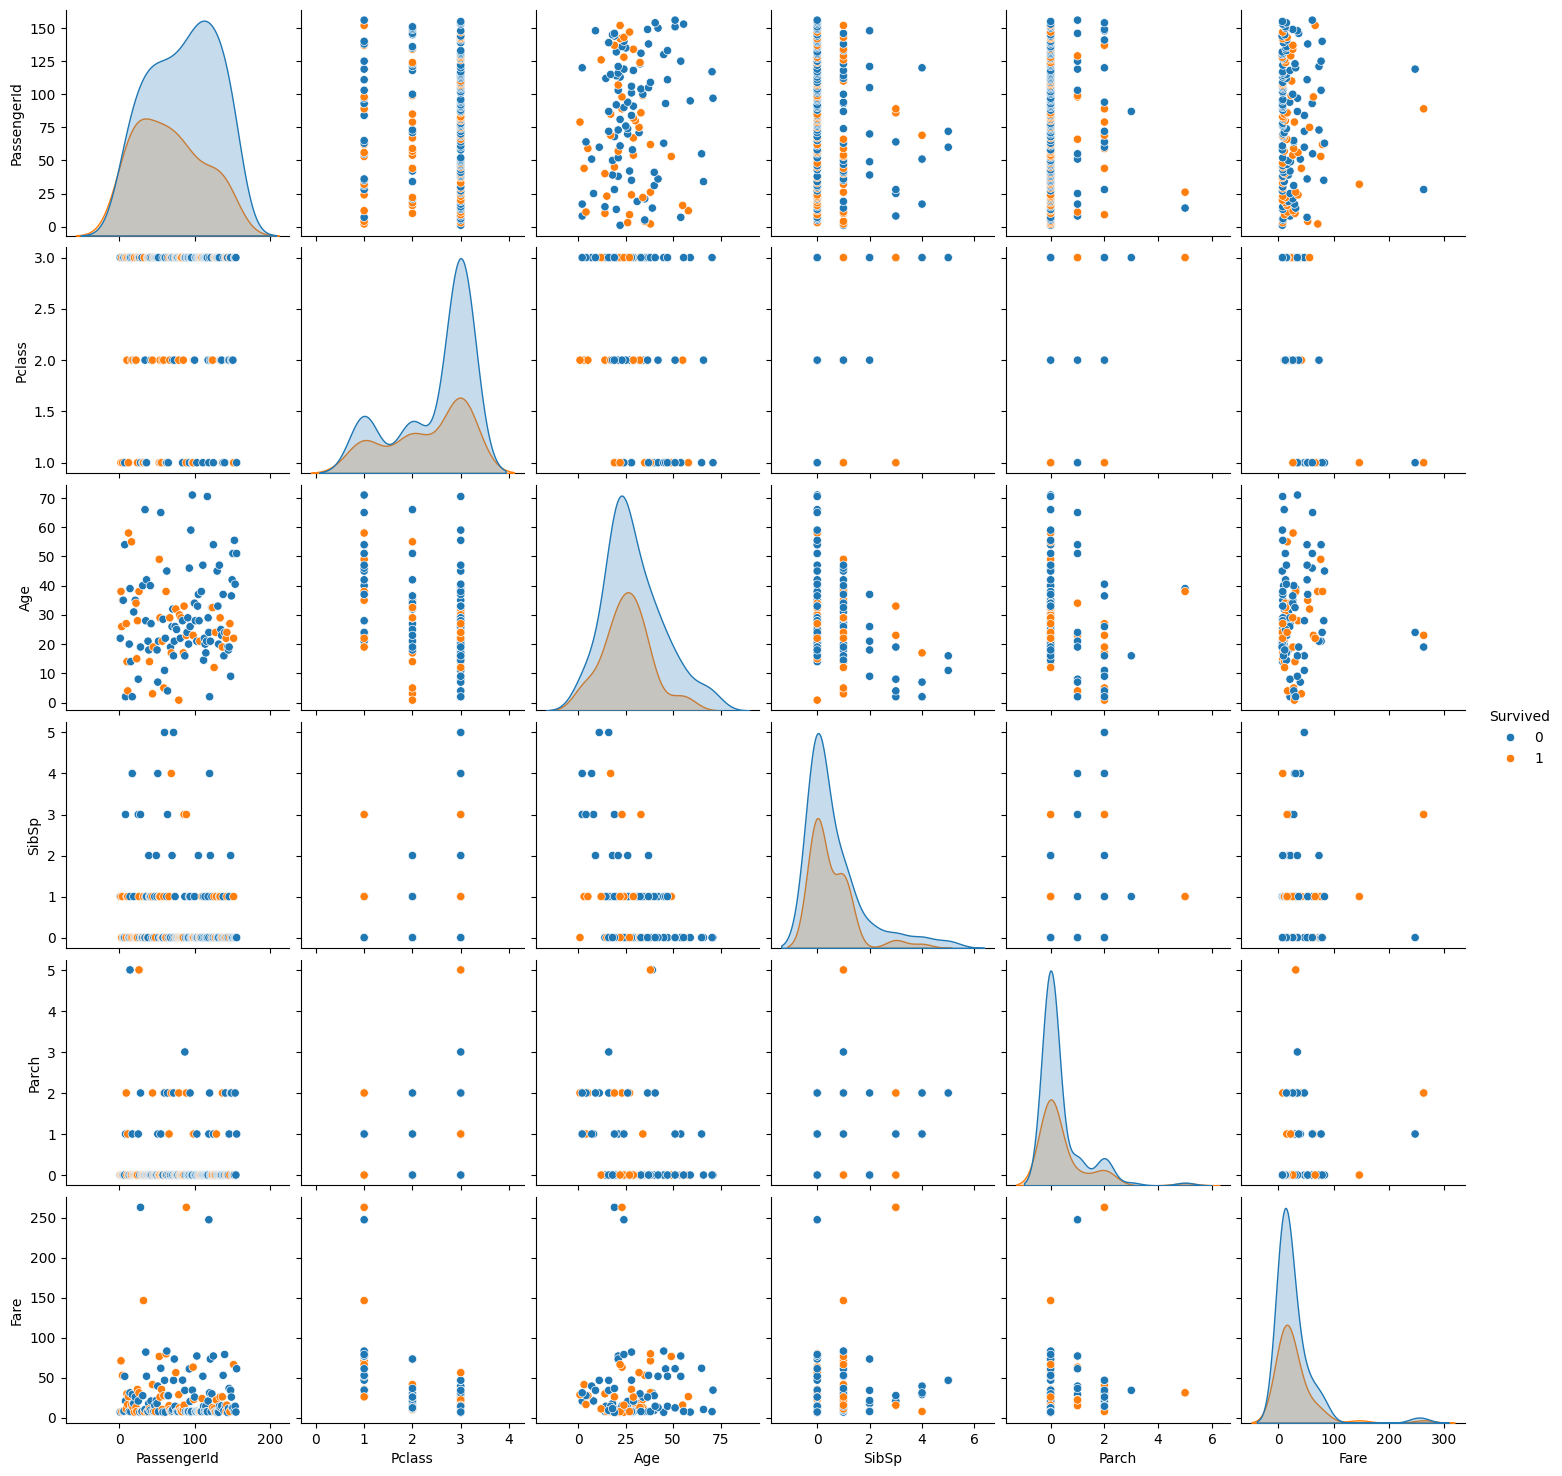

In [45]:
sns.pairplot(df,hue="Survived")

In [46]:
df=df.drop(columns=["PassengerId","Name","Cabin","Ticket"])
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
151,1,1,female,22.0,1,0,66.6000,S
152,0,3,male,55.5,0,0,8.0500,S
153,0,3,male,40.5,0,2,14.5000,S
154,0,3,male,NaN,0,0,7.3125,S


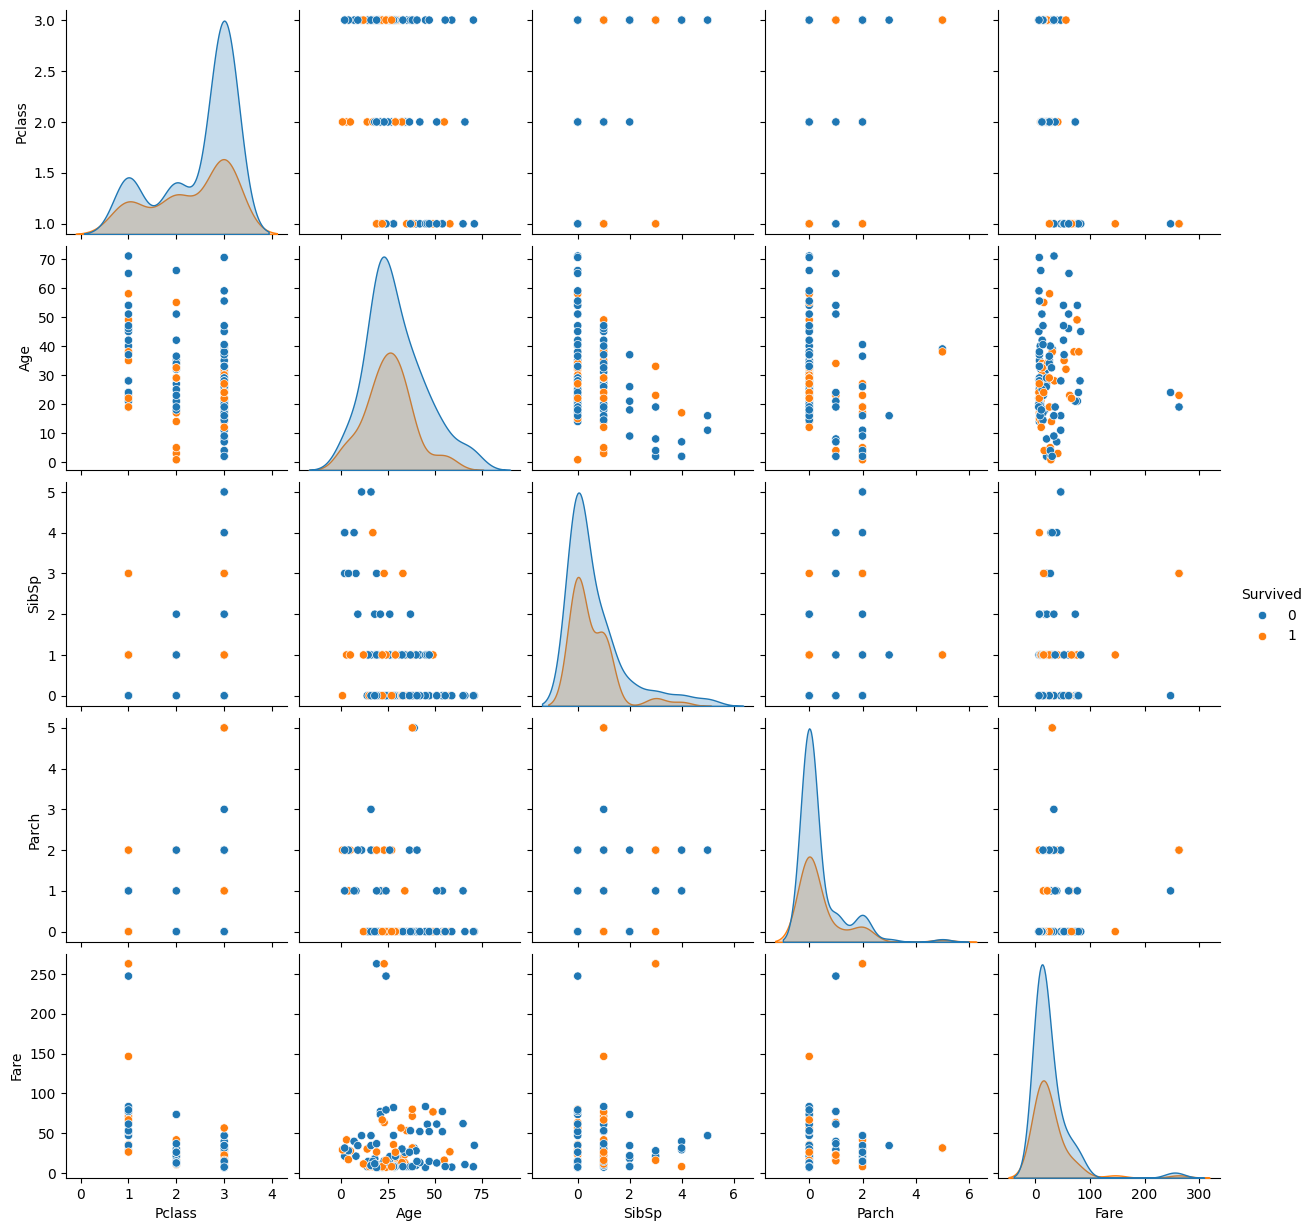

In [47]:
sns.pairplot(df,hue="Survived")

In [48]:
df.isnull().sum()

Survived     0
Pclass       0
Sex          0
Age         30
SibSp        0
Parch        0
Fare         0
Embarked     1
dtype: int64

In [49]:
df["Age"]=df["Age"].interpolate()

In [50]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    1
dtype: int64

In [51]:
df=df.dropna()

In [52]:
from summarytools import dfSummary
dfSummary(df)

No,Variable,Stats / Values,Freqs / (% of Valid),Graph,Missing
1,Survived[int64],Mean (sd) : 0.3 (0.5)min < med < max:0.0 < 0.0 < 1.0IQR (CV) : 1.0 (0.7),2 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOXRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjguMywgaHR0cHM6Ly9tYXRwbG90bGliLm9yZy/H5lhTAAAACXBIWXMAAA9hAAAPYQGoP6dpAAABf0lEQVR4nO3cQWrCQBiG4ZkiopsEETyMh+hhewhvI2VcVClouuumUGNU2g+eZ535yeIlYTZ/HYahwH/38tcvAGPMrj1Qa12WUuYT538Ow3CceBa+/RpqrXW5Xq9fu65bTRl+OBzea61vYuVe176o867rVtvt9tj3/emWwa21xW63W+33+3kpRajc5eqvv5RS+r4/bTabjwnzlxPOwA8uU0QQKhGESgShEkGoRBAqEYRKBKESQahEECoRhEoEoRJBqEQQKhGESgShEkGoRBAqEYRKBKESQahEECoRhEoEoRJBqEQQKhGESgShEmHUkjQY45m7dIXKQzx7l65QeZSn7tIVKg/1rF26LlNEECoRhEoEoRJBqEQQKhGESgShEkGoRBAqEYRKBKESQahEECoRhEoEoRJBqEQQKhGESgShEkGoRBAqEYRKBKESQahEECoRhEoEoRJBqEQQKhGESoRR+1Fba4tbB7fWFufzeVZK6WqtN78YcbrL5TKb2sq1Z74AKnBOfXzSxlwAAAAASUVORK5CYII="">",0(0.0%)
2,Pclass[int64],Mean (sd) : 2.4 (0.8)min < med < max:1.0 < 3.0 < 3.0IQR (CV) : 1.0 (3.1),3 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOXRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjguMywgaHR0cHM6Ly9tYXRwbG90bGliLm9yZy/H5lhTAAAACXBIWXMAAA9hAAAPYQGoP6dpAAABjklEQVR4nO3dUWrqQBiG4ZkiojcJIrgYF9HFdhHuRsp4cVoOaLqCVk0Nnu/keW7jhPHnRQwEpg7DUOBf9/LsDcAtFs/eAP+PWuu6lLIcufzvMAwf310UKg9Ra11vt9vXrus2Y9afTqf3Wuvbd7EKlUdZdl232e/3H33ff96zsLW2OhwOm+PxuCylCJXp9X3/udvt/oxYuv7poocpIgiVCEIlglCJIFQiCJUIQiWCUIkgVCIIlQhCJYJQiSBUIgiVCEIlglCJIFQiCJUIQiWCUIkgVCIIlQhCJYJQiSBUIgiVCEIlglCJIFQiCJUIQiWCUIkgVCIIlQhCJYJQiSBUIgiVCEIlglCJIFQiCJUIjpicwJSnLM/V1VAN/T5Tn7I8Vz+GauijTHrK8lxd+0U19JGmOmV5rm76j2roPJunfiIIlQhCJYJQiSBUIgiVCEIlglCJIFQiCJUIQiWCUIkgVCIIlQhCJYJQiXDTi9OttdW9N26trc7n86KU0tVa795YsO5yuSxmOLNffe9rn/kCBON2/PUoVfEAAAAASUVORK5CYII="">",0(0.0%)
3,Sex[object],1. male2. female,100 (64.5%)55 (35.5%),"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAAAuCAYAAAA/ZmtKAAAAOXRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjguMywgaHR0cHM6Ly9tYXRwbG90bGliLm9yZy/H5lhTAAAACXBIWXMAAA9hAAAPYQGoP6dpAAABOUlEQVR4nO3bwWnDQBRF0TdBmGSjQQhUjIpIsSlC3QihWcTGm8nCkA78xvN9TwXf+GJso5dqrQIckqQvSZfWh+DfvdZ6bX3EMwzzPH+P4zi1PgQPpZQjpfQTMbhhHMdpXddrzvnW+ph3d57n57Zt077vF0nxYpOknPNtWZbf1sdA0uNrTUgfrQ/A+yA22BAbbIgNNsQGG2KDDbHBhthgQ2ywITbYEBtsiA02xAYbYoMNscFmkB4P7bU+BPHfh6GUcmzbNinwQ3s9KaUcku6t73gGBi+vJ+zgJTHlg0v0T7awnxI9Cj3lizyL61HYKV/0WVyPok/5+IX9QvhTFzbEBhtigw2xwYbYYENssCE22BAbbIgNNsQGG2KDDbHBhthgQ2ywITbYhJ3yRXxNvQs95Ys8i+sRgxfY/AEKW2rfw3Mb/AAAAABJRU5ErkJggg=="">",0(0.0%)
4,Age[float64],Mean (sd) : 28.2 (14.4)min < med < max:0.8 < 26.0 < 71.0IQR (CV) : 16.0 (2.0),77 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOXRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjguMywgaHR0cHM6Ly9tYXRwbG90bGliLm9yZy/H5lhTAAAACXBIWXMAAA9hAAAPYQGoP6dpAAACyUlEQVR4nO3dTY7aMBiA4c9lgPAjRwgJdlygUhcsc4g5bI8wC07ADdghIQSCAREC3ZRKVRkgtlPyhffZG6LRO56x4yjmfD4LUHbfnn0BwCPenn0BtxhjWiLScBx+OJ/Pu5DXg+cpbajGmFa/33+31vZcxq/X66Ux5iexVkNpQxWRhrW2lyTJLo7jfZ6Bq9UqmkwmvcVi0RARQq2AMocqIiJxHO8Hg8Gnw9BW8IvB07CYggqEChVK/6ffVZZldRGxxhjXj2DXoEQqGep2u62nafpjNBrVarVaroXYBbsG5VLJUA+Hw1sURe3xeLwfDofLvOPZNSifSoZ60el0XHcMRNg1KBUWU1CBUKECoUIFQoUKhAoVCBUqECpUIFSoQKhQgVChAqFChUrf6/fheUyQI4KBEeoVvscEOSIYHqFe4XNMkCOCxSDUGzyOCXJEMDAWU1CBUKECoUIFQoUKhAoVCBUqECpUIFSoQKhQgVChAqFCBUKFCoQKFQgVKhAqVCBUqECoUIFQoQKhQgWemSoAj1qHR6iB8ah1MQg1MB61LgahFoRHrcNiMQUVCp1RjTEtEWk4Dren06ke8no04NWY1xUWqjGm1e/33621PZfxaZpGWZZ93+/3HyLi+lIzVXg15tfuhuoxK9putztIkmQdx3HuH/psNutNp9P28XisOXy3Srwa82s3Q/WZFS8zYrPZ/HBZVCyXy5ddVPBqzH/dm1Eb1tpekiS7vLPiK86IKM5D/6PGcZz7N/yVZ0SEx/YUVGDDv2Kqes6AUCukyucMCLVCnn3OwPMGz83ZnFAr6BnnDHxv8NybzQkVoThvZT4ymxMqgnLZyvzt5mxOqPjDc8eg0ENEhAoR8d8xKPoQEaFCRPwPxBR9y5xQ8RfXHYOib5lzCxUqPDSjrlarKO8HbzabSERku91G8/m8/T/Ha/1urdftO/6Rvn4BpaK+sJ65CT0AAAAASUVORK5CYII="">",0(0.0%)
5,SibSp[int64],Mean (sd) : 0.6 (1.1)min < med < max:0.0 < 0.0 < 5.0IQR (CV) : 1.0 (0.6),6 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAA

In [53]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.00,1,0,7.2500,S
1,1,1,female,38.00,1,0,71.2833,C
2,1,3,female,26.00,0,0,7.9250,S
3,1,1,female,35.00,1,0,53.1000,S
4,0,3,male,35.00,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
151,1,1,female,22.00,1,0,66.6000,S
152,0,3,male,55.50,0,0,8.0500,S
153,0,3,male,40.50,0,2,14.5000,S
154,0,3,male,45.75,0,0,7.3125,S


In [63]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer

categorical_cols=["Embarked","Sex"]
preprocessor=ColumnTransformer(
                                transformers=[
                                    ("OneHot", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
                                    ],
                                remainder="passthrough"
                                )
pipe=Pipeline( [
                ("preprocessing",preprocessor),
               ("scaler",StandardScaler()),
               ("classifier",DecisionTreeClassifier(max_depth=4))
               ])
pipe

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('OneHot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Embarked', 'Sex'])])),
                ('scaler', StandardScaler()),
                ('classifier', DecisionTreeClassifier(max_depth=4))])

In [64]:
X=df.drop(columns="Survived")
y=df["Survived"]

In [65]:
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.00,1,0,7.2500,S
1,1,female,38.00,1,0,71.2833,C
2,3,female,26.00,0,0,7.9250,S
3,1,female,35.00,1,0,53.1000,S
4,3,male,35.00,0,0,8.0500,S
...,...,...,...,...,...,...,...
151,1,female,22.00,1,0,66.6000,S
152,3,male,55.50,0,0,8.0500,S
153,3,male,40.50,0,2,14.5000,S
154,3,male,45.75,0,0,7.3125,S


In [66]:
scores=cross_val_score(pipe,X,y,cv=5)
scores

array([0.80645161, 0.77419355, 0.83870968, 0.70967742, 0.64516129])

In [67]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
y_pred_cval=cross_val_predict(pipe,X,y,cv=5)
y_pred_cval

array([0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0], dtype=int64)

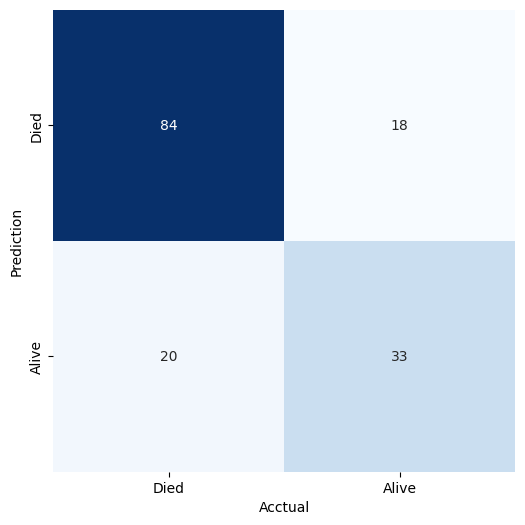

In [69]:
from sklearn.metrics import confusion_matrix
labels=["Died","Alive"]
conf=confusion_matrix(y,y_pred_cval)
plt.figure(figsize=[6,6])
sns.heatmap(conf, cmap="Blues", annot=True, square=True, cbar=False,
            xticklabels=labels,
            yticklabels=labels);
plt.xlabel("Acctual")
plt.ylabel("Prediction")
plt.show()